In [ ]:
import pandas as pd

In [ ]:
year_by_df_ott_genre=pd.read_csv('2021-2025_df_ott_genre.csv', encoding='cp949')
# '시점', '구분별(1)', '구분별(2)' 컬럼을 기준으로 데이터를 그룹화합니다.
year_and_age_grouped_data = year_by_df_ott_genre.groupby(['시점', '구분별(1)', '구분별(2)']).sum(numeric_only=True)
display(year_and_age_grouped_data)

응답자수 (명)  영화 (%)  예능/오락(개인방송 콘텐츠 포함) (%)  드라마 (%)  \
시점   구분별(1) 구분별(2)                                                       
2021 연령     만10-19세     880.1     4.0                    59.1      7.7   
            만10대미만      174.5     0.4                    40.8      0.4   
            만20-29세    1381.4    11.7                    54.6     23.0   
            만30-39세    1390.1    12.4                    41.8     23.3   
            만40-49세    1585.9    13.8                    40.3     24.2   
            만50-59세    1580.6     7.9                    38.5     23.2   
            만60-69세    1025.7     3.4                    39.7     20.4   
2022 연령     만10-19세     874.5     5.0                    62.7      6.1   
            만10대미만      130.7     0.0                    53.4      0.0   
            만20-29세    1321.5    10.9                    56.7     21.6   
            만30-39세    1339.3    12.3                    49.6     24.2   
            만40-49세    1589.2     9.8                    43.9     24.1   
            만50-59세    1648.3     6.7                    49.0     16.8   
            만60-69세    1197.2     3.2                    52.8     11.9   
2023 연령     만10-19세     964.5     2.9                    68.8      6.2   
            만10대미만      123.7     0.0                    31.8      1.3   
            만20-29세    1168.4     7.8                    59.1     20.4   
            만30-39세    1318.7     9.9                    52.4     22.8   
            만40-49세    1578.4    13.9                    39.6     22.9   
            만50-59세    1653.5     8.4                    46.9     15.9   
            만60-69세    1317.0     3.2                    49.9     13.3   
2024 연령     만10-19세     856.6     7.8                    66.9      6.6   
            만10대미만       82.4     0.0                    46.2      0.0   
            만20-29세     999.3    11.1                    65.6     14.5   
            만30-39세    1195.6    15.6                    50.4     20.0   
            만40-49세    1381.6    16.9                    48.0     22.3   
            만50-59세    1486.0     8.9                    49.4     21.1   
            만60-69세    1226.1     4.1                    56.6     13.9   
2025 연령     만10-19세     754.3     4.6                    72.4      5.4   
            만10대미만       73.5     0.0                    57.1      0.0   
            만20-29세     979.8    11.1                    69.3      9.5   
            만30-39세    1172.5    15.1                    62.0     17.0   
            만40-49세    1346.7    12.3                    56.2     22.4   
            만50-59세    1480.5    10.4                    56.2     17.0   
            만60-69세    1277.7     4.2                    58.9     16.9   

                     교양/다큐멘터리 (%)  교육/학습 (%)  애니메이션(만화) (%)  스포츠 (%)  뉴스 (%)  \
시점   구분별(1) 구분별(2)                                                             
2021 연령     만10-19세           3.3        9.5           13.2      2.0     0.6   
            만10대미만            0.6        8.7           47.8      0.3     0.9   
            만20-29세           2.2        2.4            0.8      3.9     1.2   
            만30-39세           4.5        0.8            2.2      8.7     5.2   
            만40-49세           3.9        1.2            0.4      7.5     7.6   
            만50-59세           3.9        1.8            0.2     10.3    12.8   
            만60-69세           5.2        0.5            0.2      7.5    20.7   
2022 연령     만10-19세           0.4        5.2           16.4      2.0     0.6   
            만10대미만            0.0       18.4           28.2      0.0     0.0   
            만20-29세           1.7        1.1            0.8      4.8     1.1   
            만30-39세           1.5        1.5            1.1      5.7     3.5   
            만40-49세           2.7        1.3            0.9      7.2     8.7   
            만50-59세           5.1        1.5            0.2      6.9    11.9   
            만60-69세           5.3        0.7            0.1      8.0    15.2   
20

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered_for_plotting = year_and_age_grouped_data.loc[(slice(None), '연령', year_and_age_grouped_data.index.get_level_values('구분별(2)') != '소계'), ]
df_plot_age_groups = df_filtered_for_plotting.unstack(level='구분별(2)')
df_plot_age_groups = df_plot_age_groups.drop('응답자수 (명)', axis=1, level=0, errors='ignore').fillna(0)

genre_columns = [col for col in year_and_age_grouped_data.columns if '%' in col and '응답자수' not in col]

genre_name_map = {
    '영화 (%)': 'Movies (%)',
    '예능/오락(개인방송 콘텐츠 포함) (%)': 'Entertainment/Variety (%)',
    '드라마 (%)': 'Drama (%)',
    '교양/다큐멘터리 (%)': 'Culture/Documentary (%)',
    '교육/학습 (%)': 'Education/Learning (%)',
    '애니메이션(만화) (%)': 'Animation (%)',
    '스포츠 (%)': 'Sports (%)',
    '뉴스 (%)': 'News (%)',
    '기타 (%)': 'Others (%)'
}

age_group_name_map = {
    '만10-19세': '10-19 years old',
    '만10대미만': 'Under 10 years old',
    '만20-29세': '20-29 years old',
    '만30-39세': '30-39 years old',
    '만40-49세': '40-49 years old',
    '만50-59세': '50-59 years old',
    '만60-69세': '60-69 years old',
    '만70세이상': '70+ years old',
    '소계': 'Total'
}

x_axis_years = df_plot_age_groups.index.get_level_values('시점').astype(int).unique()
age_group_categories = df_plot_age_groups.columns.get_level_values(1).unique()


### Movies (%) Viewership Trends

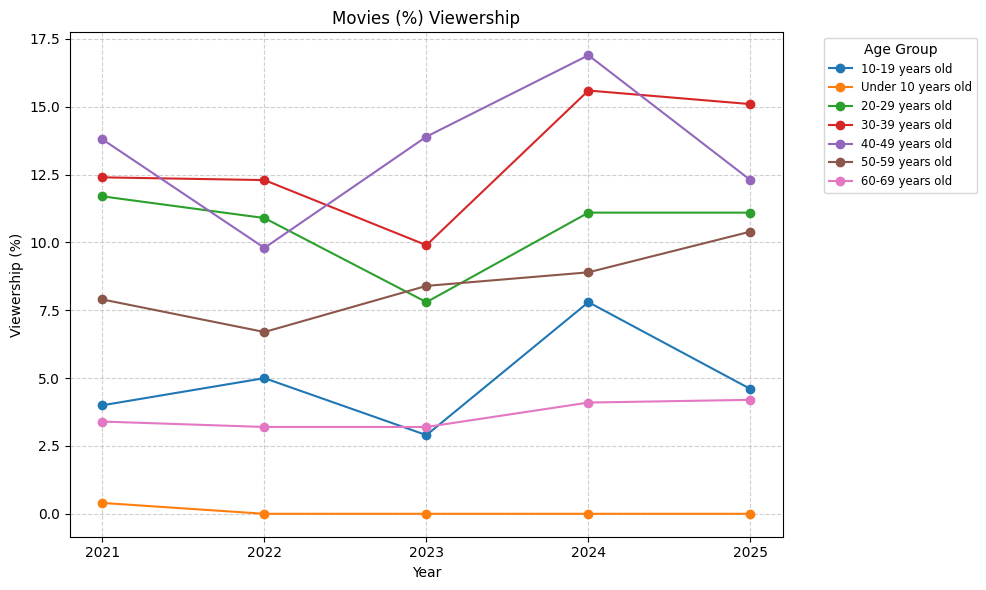

In [ ]:
# Plot for '영화 (%)'
genre = '영화 (%)'
plt.figure(figsize=(10, 6))
for age_group in age_group_categories:
    if (genre, age_group) in df_plot_age_groups.columns:
        english_age_label = age_group_name_map.get(age_group, age_group)
        plt.plot(x_axis_years, df_plot_age_groups[(genre, age_group)], marker='o', label=english_age_label)
plt.title(f'{genre_name_map.get(genre, genre)} Viewership')
plt.xlabel('Year')
plt.ylabel('Viewership (%)')
plt.xticks(x_axis_years)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Entertainment/Variety (%) Viewership Trends

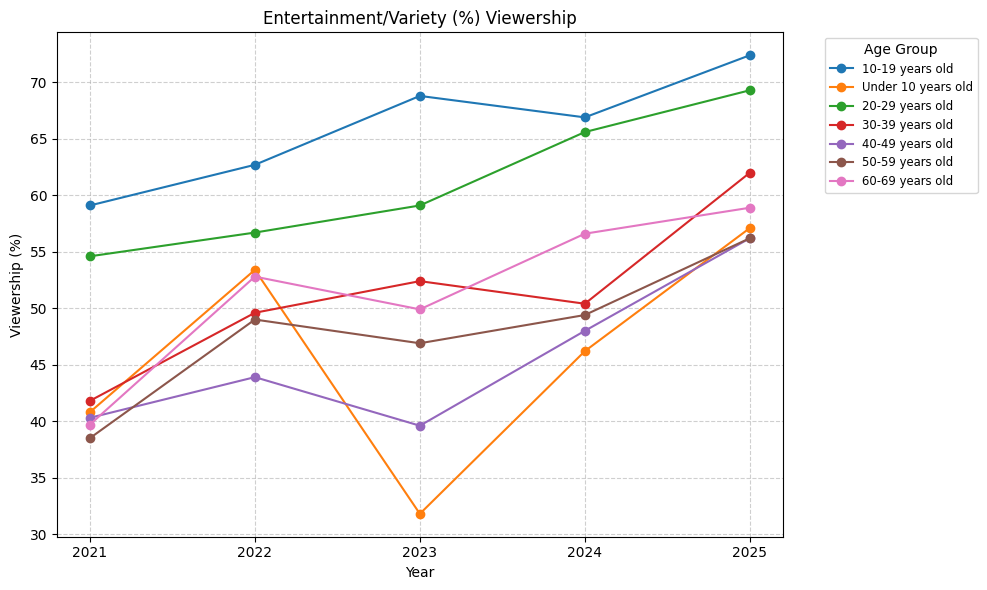

In [ ]:
# Plot for '예능/오락(개인방송 콘텐츠 포함) (%)'
genre = '예능/오락(개인방송 콘텐츠 포함) (%)'
plt.figure(figsize=(10, 6))
for age_group in age_group_categories:
    if (genre, age_group) in df_plot_age_groups.columns:
        english_age_label = age_group_name_map.get(age_group, age_group)
        plt.plot(x_axis_years, df_plot_age_groups[(genre, age_group)], marker='o', label=english_age_label)
plt.title(f'{genre_name_map.get(genre, genre)} Viewership')
plt.xlabel('Year')
plt.ylabel('Viewership (%)')
plt.xticks(x_axis_years)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Drama (%) Viewership Trends

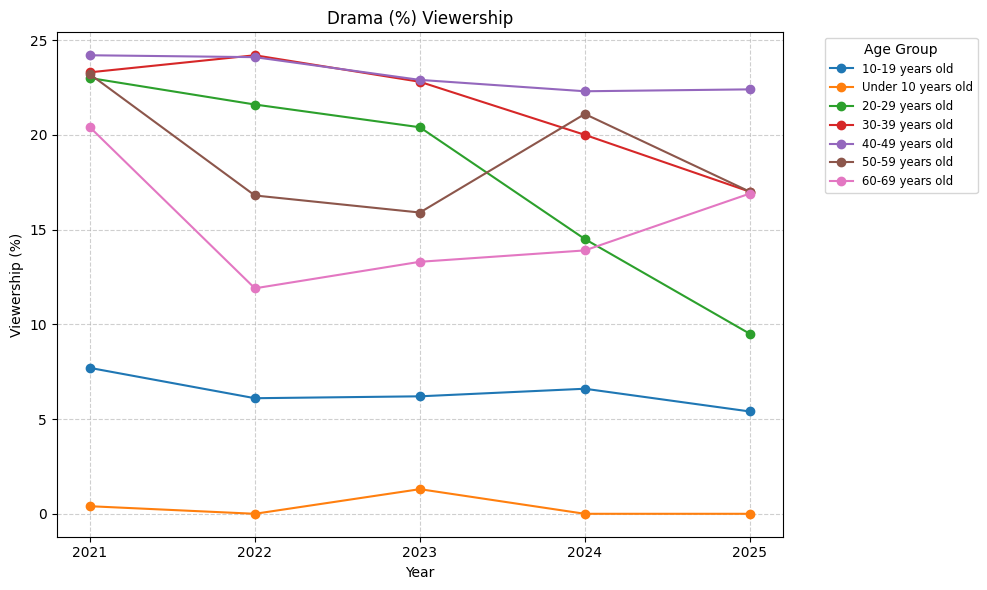

In [ ]:
# Plot for '드라마 (%)'
genre = '드라마 (%)'
plt.figure(figsize=(10, 6))
for age_group in age_group_categories:
    if (genre, age_group) in df_plot_age_groups.columns:
        english_age_label = age_group_name_map.get(age_group, age_group)
        plt.plot(x_axis_years, df_plot_age_groups[(genre, age_group)], marker='o', label=english_age_label)
plt.title(f'{genre_name_map.get(genre, genre)} Viewership')
plt.xlabel('Year')
plt.ylabel('Viewership (%)')
plt.xticks(x_axis_years)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Culture/Documentary (%) Viewership Trends

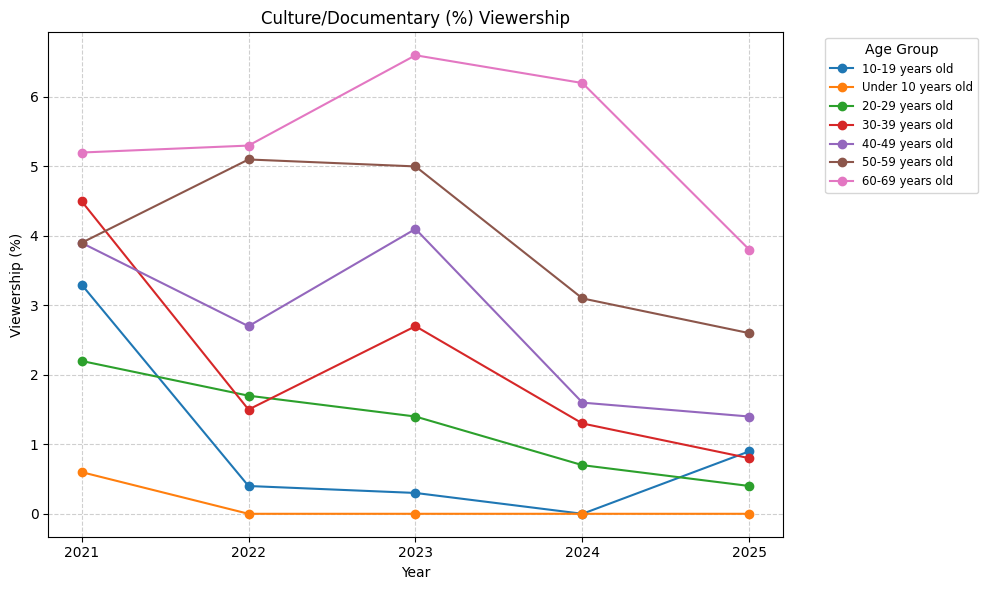

In [ ]:
# Plot for '교양/다큐멘터리 (%)'
genre = '교양/다큐멘터리 (%)'
plt.figure(figsize=(10, 6))
for age_group in age_group_categories:
    if (genre, age_group) in df_plot_age_groups.columns:
        english_age_label = age_group_name_map.get(age_group, age_group)
        plt.plot(x_axis_years, df_plot_age_groups[(genre, age_group)], marker='o', label=english_age_label)
plt.title(f'{genre_name_map.get(genre, genre)} Viewership')
plt.xlabel('Year')
plt.ylabel('Viewership (%)')
plt.xticks(x_axis_years)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Education/Learning (%) Viewership Trends

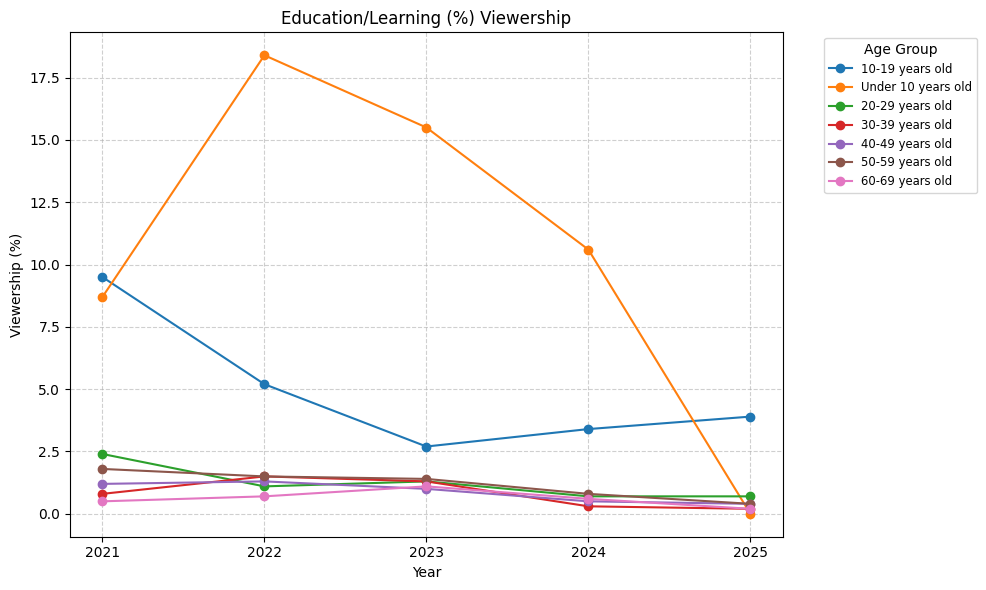

In [ ]:
# Plot for '교육/학습 (%)'
genre = '교육/학습 (%)'
plt.figure(figsize=(10, 6))
for age_group in age_group_categories:
    if (genre, age_group) in df_plot_age_groups.columns:
        english_age_label = age_group_name_map.get(age_group, age_group)
        plt.plot(x_axis_years, df_plot_age_groups[(genre, age_group)], marker='o', label=english_age_label)
plt.title(f'{genre_name_map.get(genre, genre)} Viewership')
plt.xlabel('Year')
plt.ylabel('Viewership (%)')
plt.xticks(x_axis_years)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Animation (%) Viewership Trends

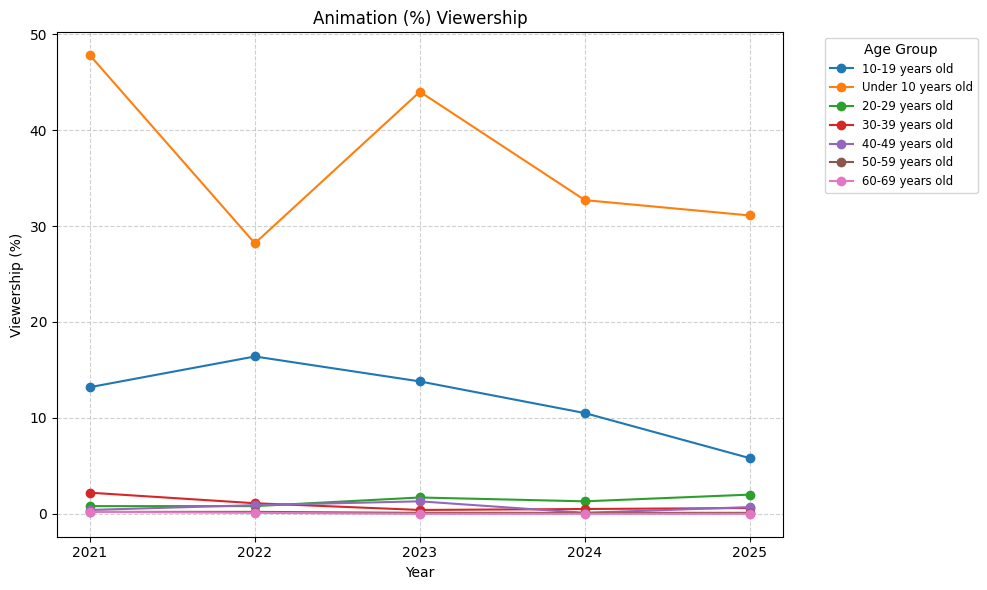

In [ ]:
# Plot for '애니메이션(만화) (%)'
genre = '애니메이션(만화) (%)'
plt.figure(figsize=(10, 6))
for age_group in age_group_categories:
    if (genre, age_group) in df_plot_age_groups.columns:
        english_age_label = age_group_name_map.get(age_group, age_group)
        plt.plot(x_axis_years, df_plot_age_groups[(genre, age_group)], marker='o', label=english_age_label)
plt.title(f'{genre_name_map.get(genre, genre)} Viewership')
plt.xlabel('Year')
plt.ylabel('Viewership (%)')
plt.xticks(x_axis_years)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Sports (%) Viewership Trends

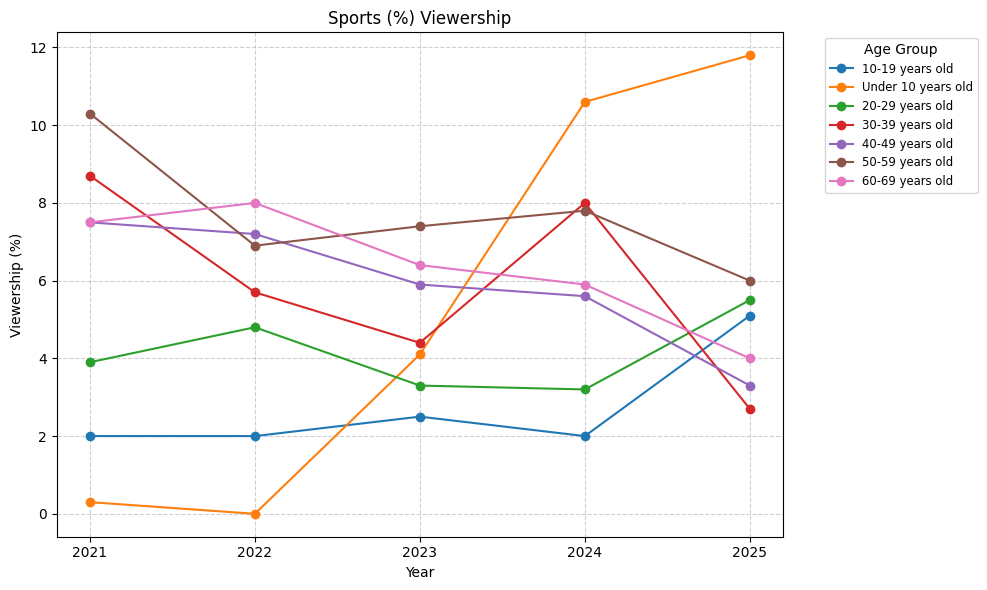

In [ ]:
# Plot for '스포츠 (%)'
genre = '스포츠 (%)'
plt.figure(figsize=(10, 6))
for age_group in age_group_categories:
    if (genre, age_group) in df_plot_age_groups.columns:
        english_age_label = age_group_name_map.get(age_group, age_group)
        plt.plot(x_axis_years, df_plot_age_groups[(genre, age_group)], marker='o', label=english_age_label)
plt.title(f'{genre_name_map.get(genre, genre)} Viewership')
plt.xlabel('Year')
plt.ylabel('Viewership (%)')
plt.xticks(x_axis_years)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### News (%) Viewership Trends

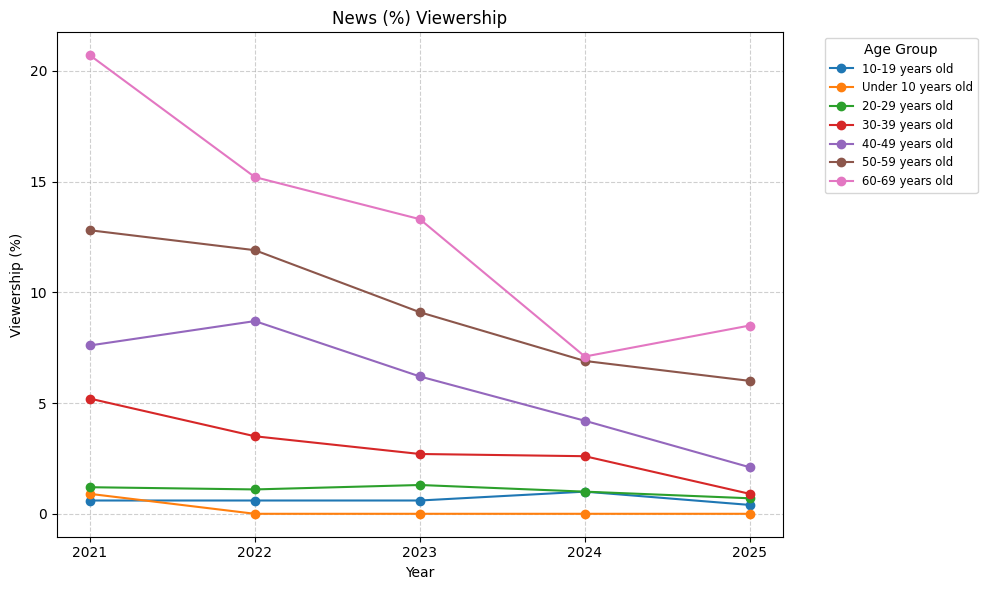

In [ ]:
# Plot for '뉴스 (%)'
genre = '뉴스 (%)'
plt.figure(figsize=(10, 6))
for age_group in age_group_categories:
    if (genre, age_group) in df_plot_age_groups.columns:
        english_age_label = age_group_name_map.get(age_group, age_group)
        plt.plot(x_axis_years, df_plot_age_groups[(genre, age_group)], marker='o', label=english_age_label)
plt.title(f'{genre_name_map.get(genre, genre)} Viewership')
plt.xlabel('Year')
plt.ylabel('Viewership (%)')
plt.xticks(x_axis_years)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Others (%) Viewership Trends

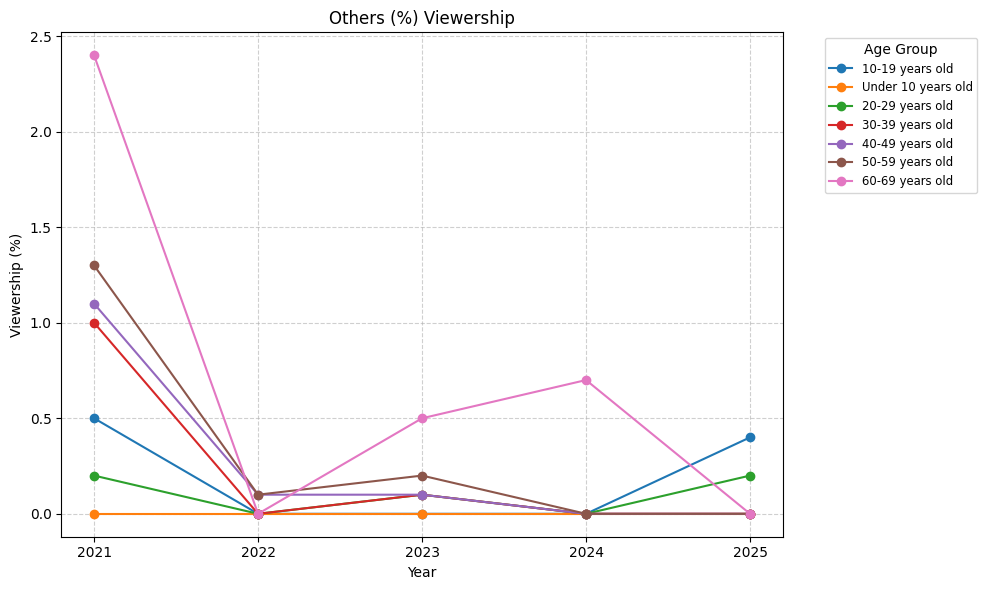

In [ ]:
# Plot for '기타 (%)'
genre = '기타 (%)'
plt.figure(figsize=(10, 6))
for age_group in age_group_categories:
    if (genre, age_group) in df_plot_age_groups.columns:
        english_age_label = age_group_name_map.get(age_group, age_group)
        plt.plot(x_axis_years, df_plot_age_groups[(genre, age_group)], marker='o', label=english_age_label)
plt.title(f'{genre_name_map.get(genre, genre)} Viewership')
plt.xlabel('Year')
plt.ylabel('Viewership (%)')
plt.xticks(x_axis_years)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()